# Topic 4 — Entanglement and Tensor Networks

In the previous topics we stored a quantum state as a vector of $2^n$ complex amplitudes, and every method we built (dense diagonalization, Lanczos, the state-vector simulator) eventually hit the same wall: the memory grows exponentially with $n$. To go beyond $n \sim 30$ we need a *compressed* representation of the wavefunction. The **matrix product state (MPS)** is such a representation, and it works because the states we actually care about — ground states of local Hamiltonians, states produced by shallow circuits — are far less entangled than a generic state in the Hilbert space.

This notebook prepares the ingredients we need before building MPS, and ends with a first application:

1. **Entanglement** — how to decide, and quantify, whether a state is entangled across a bipartition. The tool is the singular value decomposition (SVD), which applied to a quantum state is called the **Schmidt decomposition**.
2. **Tensor networks** — a graphical language, and a software toolkit ([`quimb`](https://quimb.readthedocs.io/)), for manipulating multi-index arrays. The $n$-qubit wavefunction *is* a tensor, and everything we did with `np.kron` and gates becomes a **tensor contraction**.
3. **Quantum circuits as tensor networks** — a circuit is nothing but a tensor network, and `quimb`'s circuit simulator lets us contract it in whichever order is cheapest.

**Setup.** `quimb` has been added to the course environment. Run `uv sync` in the repository folder (then restart the kernel) so that the imports below work.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import quimb as qu
import quimb.tensor as qtn

np.set_printoptions(precision=4, suppress=True, linewidth=120)

---

## 1. Entanglement

### 1.1 Product states and entangled states

Split the $n$ qubits into two groups $A$ and $B$ (a **bipartition**). The Hilbert space factorizes as
$$
\mathcal{H} = \mathcal{H}_A \otimes \mathcal{H}_B, \qquad d_A := \dim \mathcal{H}_A = 2^{|A|}, \quad d_B := \dim \mathcal{H}_B = 2^{|B|}.
$$

- A state is a **product state** (not entangled between $A$ and $B$) if it can be written as
$$
|\psi\rangle_{AB} = |\chi\rangle_A \otimes |\eta\rangle_B .
$$
  *Example 1.* Writing two-qubit states as $|\sigma_1\sigma_0\rangle$ with $A=\{1\}$, $B=\{0\}$,
  $$
  |\psi_1\rangle = \tfrac{1}{2}\bigl(|00\rangle - |01\rangle + |10\rangle - |11\rangle\bigr)
  = \tfrac{1}{\sqrt 2}\bigl(|0\rangle + |1\rangle\bigr)_1 \otimes \tfrac{1}{\sqrt 2}\bigl(|0\rangle - |1\rangle\bigr)_0
  = |+\rangle_1 \otimes |-\rangle_0 .
  $$
  *Example 2.* Three qubits $|\sigma_2\sigma_1\sigma_0\rangle$ with $A = \{2, 1\}$, $B = \{0\}$:
  $$
  |\psi_2\rangle = \tfrac{1}{\sqrt 2}\bigl(|000\rangle + |110\rangle\bigr)
  = \tfrac{1}{\sqrt 2}\bigl(|00\rangle + |11\rangle\bigr)_{A} \otimes |0\rangle_{B} .
  $$
  This is a product state *between $A$ and $B$*, even though the two qubits inside $A$ are entangled with each other.

- A state is **entangled** between $A$ and $B$ if no such factorization exists:
$$
|\psi\rangle_{AB} \neq |\chi\rangle_A \otimes |\eta\rangle_B \quad \text{for any } |\chi\rangle_A,\ |\eta\rangle_B .
$$
  *Examples.* The Bell state $|\Phi\rangle = \tfrac{1}{\sqrt 2}(|00\rangle + |11\rangle)$ with $A=\{1\}$, $B=\{0\}$; or $|\psi_2\rangle$ above with the *different* bipartition $A=\{2\}$, $B=\{1,0\}$.

Entanglement is therefore a property of a state **together with** a bipartition.

**How do we test whether a given $|\psi\rangle_{AB} \in \mathcal{H}_A \otimes \mathcal{H}_B$ is entangled?** "Try to factorize it" is not an algorithm. The singular value decomposition is.

### 1.2 Singular value decomposition (SVD)

For any $m \times n$ matrix $M$ (view it as a linear map $\mathbb{C}^n \to \mathbb{C}^m$) there exist matrices $U$, $S$, $V$ such that
$$
M = U\, S\, V^\dagger , \qquad k := \min(m, n),
$$
with

- $U = \bigl(\,\vec u_1 \cdots \vec u_k\,\bigr)$: an $m \times k$ matrix with **orthonormal columns**, $U^\dagger U = \mathbb{1}_k$ (but in general $UU^\dagger \neq \mathbb{1}_m$);
- $S = \mathrm{diag}(s_1, s_2, \ldots, s_k)$: **real, non-negative**, conventionally sorted $s_1 \ge s_2 \ge \cdots \ge s_k \ge 0$. The $s_i$ are the **singular values**;
- $V = \bigl(\,\vec v_1 \cdots \vec v_k\,\bigr)$: an $n \times k$ matrix with orthonormal columns, $V^\dagger V = \mathbb{1}_k$ (and $VV^\dagger \neq \mathbb{1}_n$ in general).

If $M$ is real, $M = U S V^T$ with real $U$, $V$.

In `numpy` / `scipy`:
```python
U, S, Vh = np.linalg.svd(M, full_matrices=False)     # or scipy.linalg.svd
```
returns `U` ($m\times k$), the vector `S` of singular values (length $k$) and `Vh` $= V^\dagger$ ($k\times n$). The default `full_matrices=True` pads `U` and `Vh` to square matrices with extra columns/rows multiplying zeros — we never need those, so always pass `full_matrices=False` (the "thin" or "economy" SVD).

*Relation to eigen-decomposition.* $M M^\dagger = U S^2 U^\dagger$ and $M^\dagger M = V S^2 V^\dagger$, so the $s_i^2$ are the eigenvalues of the Hermitian, positive-semidefinite matrices $MM^\dagger$ and $M^\dagger M$, with eigenvectors $\vec u_i$ and $\vec v_i$ respectively. Unlike the eigen-decomposition, the SVD exists for *every* matrix, square or not.

### 1.3 Schmidt decomposition

Choose orthonormal bases $\{|a\rangle_A\}$ of $\mathcal{H}_A$ and $\{|b\rangle_B\}$ of $\mathcal{H}_B$ (for qubits: the computational basis). Any state can be expanded as
$$
|\psi\rangle_{AB} = \sum_{a=1}^{d_A} \sum_{b=1}^{d_B} \psi_{ab}\, |a\rangle \otimes |b\rangle .
$$
The key observation is that the coefficients $\psi_{ab}$ form a $d_A \times d_B$ **matrix**
$$
M = \begin{pmatrix} \psi_{11} & \cdots & \psi_{1 d_B} \\ \vdots & & \vdots \\ \psi_{d_A 1} & \cdots & \psi_{d_A d_B} \end{pmatrix},
$$
to which we can apply the SVD, $M = U S V^\dagger$, i.e. $\psi_{ab} = \sum_{i=1}^{k} U_{ai}\, s_i\, [V^\dagger]_{ib}$. Substituting back,
$$
\begin{aligned}
|\psi\rangle_{AB} &= \sum_{a,b,i} U_{ai}\, s_i\, [V^\dagger]_{ib}\; |a\rangle \otimes |b\rangle \\
&= \sum_{i=1}^{k} s_i \Bigl(\sum_a |a\rangle\, U_{ai}\Bigr) \otimes \Bigl(\sum_b |b\rangle\, V^*_{bi}\Bigr) \\
&=: \sum_{i=1}^{k} s_i\, |u_i\rangle_A \otimes |v_i\rangle_B ,
\end{aligned}
$$
where
$$
|u_i\rangle_A := \sum_a |a\rangle\, U_{ai}, \qquad |v_i\rangle_B := \sum_b |b\rangle\, V^*_{bi}, \qquad i = 1, \ldots, k .
$$
This is the **Schmidt decomposition**. Its ingredients are orthonormal:
$$
\langle u_i | u_j \rangle = \sum_{a,a'} U^*_{ai} U_{a'j} \langle a | a' \rangle = \sum_a U^*_{ai} U_{aj} = [U^\dagger U]_{ij} = \delta_{ij},
\qquad
\langle v_i | v_j \rangle = \sum_{b} V_{bi} V^*_{bj} = [V^\dagger V]_{ji} = \delta_{ij} .
$$
and normalization of $|\psi\rangle$ becomes
$$
\langle \psi | \psi \rangle = \sum_{i=1}^{k} s_i^2 = 1 .
$$

- $k$ = number of **nonzero** singular values is called the **Schmidt rank** (numerically: the number of $s_i$ above some tolerance, e.g. $10^{-10}$).
- $k = 1 \iff$ product state. **Entangled $\iff k \ge 2$.** This is the test we were looking for.
- The singular values also *quantify* entanglement. The **entanglement entropy**
$$
S_A = -\sum_{i} s_i^2 \ln s_i^2
$$
vanishes for a product state and is maximal, $\ln \min(d_A, d_B)$, when all $s_i$ are equal. (If you know density matrices: the reduced density matrix is $\rho_A = \mathrm{Tr}_B |\psi\rangle\langle\psi| = M M^\dagger = \sum_i s_i^2 |u_i\rangle\langle u_i|$, so the $s_i^2$ are its eigenvalues and $S_A$ its von Neumann entropy.)

**Pictorially.** Draw a tensor as a box and each of its indices as a leg. The Schmidt decomposition of $\psi_{ab}$ is then

```
      A   B                 A              B
      |   |                 |              |
    [  ψ  ]      =        [ U ]---(S)---[ V† ]
```

A leg connecting two boxes is a summed index (here the Schmidt index $i$); an open leg is a free index. We will develop this language in Section 2.

### 1.4 From the state vector to the matrix $\psi_{ab}$

We store an $n$-qubit state in the convention of the previous notebooks: the basis state $|\sigma_{n-1} \cdots \sigma_1 \sigma_0\rangle$ sits at integer index $a = \sum_j \sigma_j 2^j$. Then
```python
T = psi.reshape([2] * n)      # T[σ_{n-1}, ..., σ_1, σ_0]
```
is the wavefunction as an $n$-index array, with **qubit $j$ on axis $n-1-j$** (the leftmost axis is the most significant bit).

- For a **contiguous cut** $A = \{n-1, \ldots, \ell\}$, $B = \{\ell-1, \ldots, 0\}$ the matrix $\psi_{ab}$ is simply
  ```python
  M = psi.reshape(2**(n - ell), 2**ell)
  ```
  with row index $a = (\sigma_{n-1}\cdots\sigma_\ell)$ and column index $b = (\sigma_{\ell-1}\cdots\sigma_0)$. No data is moved — this is why our storage convention is convenient.
- For a **general** $A$, first `np.transpose` the axes so that those of $A$ come first (keeping the order within $A$ and within $B$), then reshape to $(2^{|A|}, 2^{|B|})$.

The cell below checks the two examples of Section 1.1.

In [ ]:
# Example 1:  |psi_1> = (|00> - |01> + |10> - |11>)/2  in the |σ1 σ0> notation.
# Index a = σ0 + 2*σ1, so the amplitude vector is ordered |00>, |01>, |10>, |11>.
psi1 = np.array([1, -1, 1, -1]) / 2

M1 = psi1.reshape(2, 2)                      # M[σ1, σ0]:  rows ↔ A={1}, cols ↔ B={0}
U, S, Vh = np.linalg.svd(M1, full_matrices=False)
print("psi_1: singular values", S, "-> Schmidt rank", np.sum(S > 1e-10))
print("       |u_1> =", U[:, 0], "  |v_1> =", Vh[0, :])   # ∝ |+> and |->  (up to a sign)

# Bell state |Φ> = (|00> + |11>)/√2
bell = np.array([1, 0, 0, 1]) / np.sqrt(2)
S = np.linalg.svd(bell.reshape(2, 2), compute_uv=False)
print("Bell : singular values", S, "-> Schmidt rank", np.sum(S > 1e-10))
print("       entanglement entropy S_A =", -np.sum(S**2 * np.log(S**2)), " (ln 2 =", np.log(2), ")")

### Exercise 1: Schmidt decomposition

**1.** Write a function `bipartition_matrix(psi, A)` that takes an $n$-qubit state vector `psi` (length $2^n$; infer $n$ from the length) and a list `A` of qubit labels, and returns the $2^{|A|} \times 2^{|B|}$ matrix $\psi_{ab}$, where $B$ is the complement of $A$. Then write `schmidt_values(psi, A)` returning the singular values $s_1 \ge s_2 \ge \cdots$ (hint: `np.linalg.svd(M, compute_uv=False)`).

**2.** Test on the states of Section 1.1 and report the Schmidt rank in each case:
   - $|\psi_1\rangle$ with $A = \{1\}$;
   - $|\psi_2\rangle = \tfrac{1}{\sqrt 2}(|000\rangle + |110\rangle)$ with $A = \{2, 1\}$ and with $A = \{2\}$;
   - the Bell state;
   - a random *product* state $|\chi\rangle \otimes |\eta\rangle$ of $n = 6$ qubits (build it with `np.kron` from two random normalized vectors);
   - a random state of $n = 6$ qubits (normalized complex Gaussian vector), across the half cut $A = \{5, 4, 3\}$.

   Are the results what you expect?

**3.** Write `schmidt_decomposition(psi, A)` returning `s`, `us`, `vs`, where `us[i]` and `vs[i]` are the vectors $|u_i\rangle_A$ and $|v_i\rangle_B$ of Section 1.3 (as arrays of length $2^{|A|}$ and $2^{|B|}$). Verify for the random state of part 2 that (i) the $|u_i\rangle$ are orthonormal, (ii) the $|v_i\rangle$ are orthonormal, and (iii) $\sum_i s_i\, |u_i\rangle\langle v_i^*|$ — i.e. `sum(s[i] * np.outer(us[i], vs[i]))` — reproduces the matrix $\psi_{ab}$.

In [ ]:
# --- Parts 1 & 3: bipartition_matrix, schmidt_values, schmidt_decomposition ---

def bipartition_matrix(psi, A):
    pass

def schmidt_values(psi, A):
    pass

def schmidt_decomposition(psi, A):
    pass

In [ ]:
# --- Part 2: tests ---

In [ ]:
# --- Part 3: verify the Schmidt decomposition of the random state ---

---

## 2. Tensor networks

### 2.1 Vectors, matrices, tensors

A **tensor** is simply an array with several indices. In code it is a `numpy` array with several axes; in a diagram it is a box with one **leg** per index:

| object | components | numpy | diagram |
|---|---|---|---|
| vector | $V_i$ | `V[n]`, 1 axis | box with 1 leg |
| matrix | $M_{ij}$ | `M[n, m]`, 2 axes | box with 2 legs |
| rank-$r$ tensor | $T_{i_1 i_2 \cdots i_r}$ | `T[i1, ..., ir]`, $r$ axes | box with $r$ legs |

```
   |            |               \ | /
  [V]        --[M]--          --( T )--
                                / | \
```

### 2.2 The $n$-qubit wavefunction is a tensor

The state vector `psi` of length $2^n$ and the array `psi.reshape([2]*n)` contain exactly the same numbers. The second view says that the wavefunction is a tensor with $n$ legs, one per qubit, each of dimension 2:
$$
\psi[\sigma_{n-1}, \sigma_{n-2}, \ldots, \sigma_0] \quad\longleftrightarrow\quad
\begin{array}{c}
\ \ |\ \ \ |\ \ \cdots\ \ | \\
\bigl[\quad\ \psi\quad\ \bigr]
\end{array}
$$
In our convention leg (axis) $0$ is qubit $n-1$ and leg $n-1$ is qubit $0$.

Exponential cost now has a graphical meaning: a box with $n$ legs of dimension 2 holds $2^n$ numbers. A tensor *network* replaces the one big box by many small boxes connected by legs, and the total number of stored numbers can be far smaller — provided the state has little entanglement (Section 1).

### 2.3 Tensor contraction

We use the **Einstein summation convention**: a repeated index is summed over. A **contraction** of two tensors sums over their shared indices; in the diagram, a summed index is a leg *connecting* two boxes, and the free indices of the result are the legs left *open*.

- Dot product $c = \vec a^{\,*} \cdot \vec b = a^*_i\, b_i$:
  ```
  [a*]--i--[b]   =   (c)          (no open legs: a scalar)
  ```
- Matrix–vector multiplication $w_i = M_{ij}\, v_j$:
  ```
  i--[M]--j--[v]   =   i--[w]     (one open leg: a vector)
  ```
- A three-tensor network:
  $$
  D_{abce} = A_{abcdg}\, B_{def}\, C_{fg}
  $$
  ```
      b   c        e
       \ /         |
   a--( A )--d--[ B ]--f--[ C ]
         \                 /
          \______ g _______/
  ```
  The indices $d$, $f$, $g$ are summed; $a$, $b$, $c$, $e$ remain open, so the result is a rank-4 tensor.

In `numpy` the convention is spelled out literally with `np.einsum`:

In [ ]:
rng = np.random.default_rng(0)

# dot product  c = a*_i b_i
a = rng.normal(size=3) + 1j * rng.normal(size=3)
b = rng.normal(size=3) + 1j * rng.normal(size=3)
c = np.einsum('i,i->', a.conj(), b)
print("dot product   :", np.allclose(c, np.vdot(a, b)))

# matrix-vector  w_i = M_ij v_j
M = rng.normal(size=(4, 3)); v = rng.normal(size=3)
w = np.einsum('ij,j->i', M, v)
print("matrix-vector :", np.allclose(w, M @ v))

# three tensors  D_abce = A_abcdg B_def C_fg
A = rng.normal(size=(2, 3, 4, 5, 6))
B = rng.normal(size=(5, 7, 8))
C = rng.normal(size=(8, 6))
D = np.einsum('abcdg,def,fg->abce', A, B, C)
print("D.shape       :", D.shape)

**Cost of a contraction.** Contracting two tensors costs (number of multiplications) the product of the dimensions of *all* indices involved, shared and open. For $w_i = M_{ij} v_j$ that is $n \cdot m$; for $\langle\psi|\psi\rangle$ with two $n$-qubit tensors it is $2^n$. A network of three or more tensors is contracted **pairwise**, and the *order* in which pairs are contracted can change the cost by orders of magnitude. Finding a good order is a hard optimization problem in general; `np.einsum(..., optimize=True)` and `quimb` search for one automatically.

### 2.4 `quimb`

[`quimb`](https://quimb.readthedocs.io/) is a Python library for tensor networks (and for the "quick and dirty" dense methods we have used so far; the `qu` namespace has e.g. `qu.pauli('X')`, `qu.rand_ket(d)`). Its tensor-network module `quimb.tensor` (imported as `qtn`) is built on three ideas:

1. A **`Tensor`** is an array together with a *name for each leg* (`inds`) and optional labels (`tags`) to find it later in a network. Because legs are named, there is no need to remember axis positions.
2. Combining tensors with `&` builds a **`TensorNetwork`**. Two tensors that share an index name are connected by that leg. Nothing is computed yet.
3. **`.contract()`** (or the shortcut `@` for two tensors) performs the contraction, summing over every index that appears twice, in an order `quimb` chooses. `.draw()` shows the diagram.

The cell below redoes the three examples of Section 2.3 in `quimb`.

In [ ]:
# 1. Tensors: array + index names (+ tags)
ta = qtn.Tensor(a, inds=('i',), tags='a')
tb = qtn.Tensor(b, inds=('i',), tags='b')
print(ta)

# dot product: `.H` takes the complex conjugate of a Tensor (index names are kept),
# and `@` contracts all shared indices.  Shared index 'i' -> summed -> scalar.
print("dot product   :", np.allclose(ta.H @ tb, np.vdot(a, b)))

# matrix-vector: name the legs of M so that its second leg matches the leg of v
tM = qtn.Tensor(M, inds=('i', 'j'), tags='M')
tv = qtn.Tensor(v, inds=('j',), tags='v')
tw = tM @ tv                        # a Tensor with the open leg 'i'
print("matrix-vector :", tw.inds, np.allclose(tw.data, M @ v))

In [ ]:
# 2. Three tensors: build the network with `&` and draw it
tA = qtn.Tensor(A, inds=('a', 'b', 'c', 'd', 'g'), tags='A')
tB = qtn.Tensor(B, inds=('d', 'e', 'f'), tags='B')
tC = qtn.Tensor(C, inds=('f', 'g'), tags='C')

tn = tA & tB & tC                  # a TensorNetwork; nothing is contracted yet
print(tn)
tn.draw(color=['A', 'B', 'C'], show_inds='all', figsize=(4, 4))

# 3. Contract.  The result is a Tensor whose legs are the open indices (in some order),
#    so we `transpose` to the order we want before comparing with np.einsum.
tD = tn.contract()
print("result legs   :", tD.inds)
print("matches einsum:", np.allclose(tD.transpose('a', 'b', 'c', 'e').data, D))

**The Schmidt decomposition as a tensor operation.** `Tensor.split(left_inds=...)` reshapes the tensor into a matrix with the listed legs as rows and the remaining legs as columns, applies the SVD, and returns the pieces as tensors connected by a new leg — exactly the picture of Section 1.3. With `get='values'` it returns just the singular values (all of them, no truncation). With `get='tensors'` and `absorb=None` it returns the three tensors $U$, $S$, $V^\dagger$; in that case `quimb` discards singular values below the relative `cutoff=1e-10` by default, so the dimension of the new bond *is* the Schmidt rank.

In [ ]:
# |psi_2> = (|000> + |110>)/√2 as a 3-leg tensor; leg 'kj' is qubit j (qubit j sits on axis n-1-j)
psi2 = np.zeros(8); psi2[0b000] = psi2[0b110] = 1 / np.sqrt(2)
T2 = qtn.Tensor(psi2.reshape(2, 2, 2), inds=('k2', 'k1', 'k0'), tags='psi')

for A in [('k2', 'k1'), ('k2',)]:
    s = T2.split(left_inds=A, method='svd', get='values')                              # all singular values
    tU, tS, tVh = T2.split(left_inds=A, method='svd', absorb=None, get='tensors')      # cutoff applied
    print(f"A = {A}: singular values {s} -> Schmidt rank {np.sum(s > 1e-10)}; bond dimension after split: {tS.shape[0]}")

# the pieces as tensors: U --(S)-- V†
tU, tS, tVh = T2.split(left_inds=('k2',), method='svd', absorb=None, get='tensors', bond_ind='i', ltags='U', stags='S', rtags='Vh')
print(tU.inds, tS.inds, tVh.inds)
(tU & tS & tVh).draw(color=['U', 'S', 'Vh'], show_inds='all', figsize=(4, 3))

**Looking ahead.** Splitting off one qubit at a time — SVD on the cut $\{n-1\} | \{n-2, \ldots, 0\}$, then on $\{n-2\}|\{n-3,\ldots,0\}$ of the right factor, and so on — turns the single $n$-leg box into a *chain* of small tensors. That chain is the **matrix product state**, the subject of the next topic. `quimb` can do it in one line; note how the bond dimensions grow toward the middle of the chain and saturate at the Schmidt rank of each cut:

In [ ]:
n = 8
psi = np.asarray(qu.rand_ket(2 ** n)).ravel()
mps = qtn.MatrixProductState.from_dense(psi, dims=[2] * n)
print("bond dimensions:", mps.bond_sizes())
mps.draw(color=[f'I{j}' for j in range(n)], show_inds='bond-size', figsize=(7, 2.5))

### Exercise 2: getting familiar with `quimb`

Each part below exercises one or two `quimb` operations. Keep `np.allclose` checks against plain `numpy` next to every step, so you always know what the `quimb` call computed. The [tensor basics tutorial](https://quimb.readthedocs.io/en/latest/tensor-basics.html) in the `quimb` documentation is a good reference.

**1. Creating tensors and contracting with `@`.** Make a random $3 \times 4$ matrix `M` and a random vector `v` of length 4. Wrap them as `qtn.Tensor` objects with `inds=('i', 'j')` and `inds=('j',)`, giving each a tag. Print them and look at `.shape`, `.inds`, `.tags` and `.data`. Then
   - build the network `tn = tM & tv` and draw it with `tn.draw(show_inds='all')`;
   - contract it in the two equivalent ways, `tM @ tv` and `tn.contract()`, and check the result against `M @ v`. What are the `inds` of the result?

**2. Renaming and reordering legs.** Make a random tensor `T` of shape $(2, 3, 4)$ with `inds=('a', 'b', 'c')`.
   - `T.transpose('c', 'a', 'b')`: check its `.shape`, and that `.data` equals `np.transpose(T.data, (2, 0, 1))`.
   - `T.reindex({'c': 'z'})`: check that the legs are renamed but `.data` is unchanged.
   - `T.fuse({'ab': ('a', 'b')})`: check that the result has shape $(6, 4)$ and that its `.data` equals `T.data.reshape(6, 4)`. This is the "matrix $\psi_{ab}$" step of Section 1.4.
   - `T.H` is the complex conjugate (same legs). Check that `T.H @ T` (all legs shared, so all are summed) equals `np.sum(np.abs(T.data)**2)` and `T.norm()**2`.

**3. Open and closed networks.** For random $3\times 3$ matrices `A`, `B`, `C`, build the following networks, draw each one, contract it, and compare with `numpy`:
   - the matrix product $(AB)_{ik} = A_{ij} B_{jk}$ (two open legs);
   - the trace $\mathrm{Tr}(AB) = A_{ij} B_{ji}$ (no open legs: a closed loop, the result is a scalar);
   - the triangle $\mathrm{Tr}(ABC) = A_{ij} B_{jk} C_{ki}$.

   What determines whether the result is a scalar, a vector or a matrix?

In [ ]:
# --- Part 1: creating tensors, contracting with @ ---
rng = np.random.default_rng(0)

M = rng.normal(size=(3, 4))
v = rng.normal(size=4)

In [ ]:
# --- Part 2: renaming and reordering legs ---
T = qtn.Tensor(rng.normal(size=(2, 3, 4)) + 1j * rng.normal(size=(2, 3, 4)), inds=('a', 'b', 'c'), tags='T')

In [ ]:
# --- Part 3: open and closed networks ---
A, B, C = (rng.normal(size=(3, 3)) for _ in range(3))

---

## 3. Quantum circuits as tensor networks

### 3.1 Gates are tensors

A single-qubit gate is a $2\times 2$ matrix $U_{\sigma'\sigma}$: a tensor with one **input** leg $\sigma$ and one **output** leg $\sigma'$. A two-qubit gate is a $4\times 4$ matrix $U_{(\sigma'_j\sigma'_k),(\sigma_j\sigma_k)}$; reshaping it to $(2,2,2,2)$ gives a tensor with two input and two output legs.

```
      σ'               σ'_j  σ'_k
      |                 |     |
     [U]               [   U    ]
      |                 |     |
      σ                σ_j   σ_k
```

Applying a gate to the state means contracting the gate's input legs with the corresponding legs of the state tensor; the output legs become the new legs of the state. This is exactly what the "efficient" state-vector simulator of notebook 03 did with `np.tensordot`: no $2^n\times 2^n$ matrix is ever built.

### 3.2 A circuit is a tensor network

The initial state $|0\cdots 0\rangle$ is a product state, i.e. $n$ one-leg tensors $|0\rangle = (1, 0)$. Each gate is a box sitting on the wire(s) of the qubits it acts on. The output state
$$
|\psi_{\rm out}\rangle = U_L \cdots U_2 U_1 |0\cdots 0\rangle
$$
is therefore a tensor network with $n$ open legs. For example, $H$ on qubit 0 followed by CNOTs on $(0,1)$ and $(1,2)$ (a GHZ state) is

```
 |0>--[H]--[  CX  ]-------------- σ_0
               |
 |0>-----------[  ]---[  CX  ]--- σ_1
                          |
 |0>----------------------[  ]--- σ_2
```

Different questions about the circuit correspond to different networks:

- **The full state.** Contract everything, leaving the $n$ legs open: $2^n$ numbers. Contracting gate by gate from left to right is the state-vector simulator ("Schrödinger" order), with cost $O(2^n)$ per gate and memory $2^n$.
- **An amplitude** $\langle b_{n-1}\cdots b_0 | \psi_{\rm out}\rangle$. Cap each open leg with the one-leg tensor $\langle b_j|$. The network is now *closed* (no open legs) and its contraction is a single number.
- **An expectation value** $\langle \psi_{\rm out} | O_j | \psi_{\rm out}\rangle$. Glue the network to its mirror image (the bra: every tensor complex-conjugated, in reverse order) with $O_j$ in between on wire $j$ and the other wires connected directly. Again a closed network.

The point of the tensor-network view is that a closed network can be contracted in **any order**, not only the Schrödinger order. For shallow circuits, or for local observables, far cheaper orders often exist: in the expectation-value network every gate outside the "light cone" of $O_j$ meets its own conjugate and cancels, $U^\dagger U = \mathbb{1}$, so only the gates that can influence qubit $j$ need to be contracted. Finding a good contraction order is a hard optimization problem in general; `quimb` delegates it to the [`cotengra`](https://cotengra.readthedocs.io/) library. This technology is what allowed classical tensor-network simulations to compete with the first "quantum supremacy" experiments.

### 3.3 `quimb.tensor.Circuit`

`quimb` bundles all of this in the `Circuit` class. The basic functions are:

| what | call |
|---|---|
| $n$ qubits in $\lvert 0\cdots 0\rangle$ | `circ = qtn.Circuit(N=n)` |
| add gates | `circ.h(i)`, `circ.x(i)`, `circ.s(i)`, `circ.cnot(i, j)`, `circ.cz(i, j)`, `circ.rx(theta, i)`, `circ.rz(theta, i)`, `circ.rzz(theta, i, j)`, … or generically `circ.apply_gate('H', i)` |
| inspect | `circ.gates`, `circ.num_gates`, `circ.draw()` (circuit diagram) |
| the tensor network | `circ.psi` (a `TensorNetwork`), `circ.psi.draw(color=[...])` |
| full state vector | `circ.to_dense()` |
| one amplitude | `circ.amplitude('0110')` |
| expectation value of `G` on qubits `where` | `circ.local_expectation(G, where)` |
| measurement shots | `circ.sample(C, seed=...)` (a generator of bitstrings) |

The rotation gates follow the same convention as the table in notebook 03: $R_x(\theta) = e^{-i\theta X/2}$, $R_{zz}(\theta) = e^{-i\theta Z\otimes Z/2}$, etc.

**Ordering warning.** `quimb` writes bitstrings with **qubit 0 first** and `to_dense()` treats qubit 0 as the **most significant** bit — the opposite of our convention, where qubit 0 is the least significant bit. The two agree only for symmetric states. To get a state vector in our ordering, ask the network directly for its legs in the order $k_{n-1}, \ldots, k_0$:
```python
psi = circ.psi.to_dense([f'k{j}' for j in range(n - 1, -1, -1)])
```
The cell below shows the basic functions on the two-qubit circuit of notebook 03 (Exercise 1, task 4).

(<Gate(label=H, params=[], qubits=(0,))>, <Gate(label=S, params=[], qubits=(0,))>, <Gate(label=CNOT, params=[], qubits=(0, 1))>)


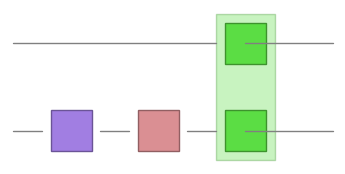

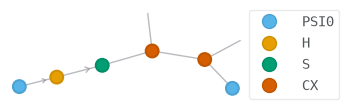

to_dense           : [0.7071+0.j     0.    +0.j     0.    +0.j     0.    +0.7071j]   (expected (|00> + i|11>)/√2)
amplitude('11')    : (4.329780281177464e-17+0.7071067811865471j)
<Z_0>              : -2.1324471573974354e-33j
<Z_0 Z_1>          : 0.999999999999999
10 samples         : ['11', '00', '00', '00', '11', '11', '11', '11', '11', '11']


In [8]:
n = 2
circ = qtn.Circuit(N=n)
circ.h(0)
circ.s(0)
circ.cnot(0, 1)
print(circ.gates)

circ.draw(figsize=(5, 2))                            # the circuit diagram ...
circ.psi.draw(color=['PSI0', 'H', 'S', 'CX'], show_tags=False, show_inds=False, figsize=(3, 3))   # ... and its tensor network

print("to_dense           :", np.asarray(circ.to_dense()).ravel(), "  (expected (|00> + i|11>)/√2)")
print("amplitude('11')    :", circ.amplitude('11'))
print("<Z_0>              :", circ.local_expectation(qu.pauli('Z'), 0))
print("<Z_0 Z_1>          :", circ.local_expectation(qu.pauli('Z') & qu.pauli('Z'), (0, 1)))   # A & B is A ⊗ B for dense operators
print("10 samples         :", list(circ.sample(10, seed=0)))

In [9]:
# Ordering: X on qubit 0 only, so the state is |σ1 σ0> = |01>, index 1 in our convention.
circ = qtn.Circuit(N=2)
circ.x(0)
print("circ.to_dense()                 :", np.asarray(circ.to_dense()).ravel().real, " <- qubit 0 is the MSB in quimb")
print("circ.psi.to_dense(['k1', 'k0']) :", np.asarray(circ.psi.to_dense(['k1', 'k0'])).ravel().real, " <- our convention")
print("amplitude('10')                 :", circ.amplitude('10'), " <- bitstrings read qubit 0 first")

circ.to_dense()                 : [0. 0. 1. 0.]  <- qubit 0 is the MSB in quimb
circ.psi.to_dense(['k1', 'k0']) : [0. 1. 0. 0.]  <- our convention
amplitude('10')                 : (1+0j)  <- bitstrings read qubit 0 first


**For further exploration.** The [circuit tutorial](https://quimb.readthedocs.io/en/latest/tensor-circuit.html) in the `quimb` documentation covers much more than the basic functions above. Some things worth looking up on your own:

- `qtn.Circuit(N, gate_contract=...)` — how two-qubit gates are stored (by default a CNOT is split into two small tensors by an SVD, exactly the operation of Section 1);
- the `optimize=` argument of `to_dense`, `amplitude`, `local_expectation`, `sample` — choosing the contraction-order optimizer (`'greedy'`, `'auto-hq'`, or a `cotengra` optimizer), and the `rehearse=True` option that reports the cost of a contraction *without* doing it;
- `circ.get_psi_reverse_lightcone(where)` — the light-cone simplification described in Section 3.2;
- `qtn.Circuit.from_openqasm2_str(...)` — importing a circuit written with `qiskit`;
- `qtn.CircuitMPS` — the same interface, but with the state stored as a matrix product state. This is the subject of the next topic.

### Exercise 3: circuits in `quimb`

**1.** Rebuild the circuit of notebook 03 Exercise 1, task 4 ($H$ on qubit 0, then $S$ on qubit 0, then CNOT with control 0 and target 1), draw it with `circ.draw()` and `circ.psi.draw(...)`, and check that `to_dense()` gives $[\tfrac{1}{\sqrt 2}, 0, 0, \tfrac{i}{\sqrt 2}]$. Then build the circuit that prepares $|\sigma_1\sigma_0\rangle = |10\rangle$ (which qubit gets the $X$?) and compare `circ.to_dense()` with `circ.psi.to_dense(['k1', 'k0'])`. Which one is in our convention?

**2.** *GHZ state.* For $n = 6$, apply $H$ to qubit 0 and then CNOTs on $(0,1), (1,2), \ldots, (4,5)$. Draw the tensor network and check `circ.psi.num_tensors`. Compute the amplitudes of `'000000'`, `'111111'` and `'000001'`; the expectation values $\langle Z_0\rangle$ and $\langle Z_0 Z_5\rangle$ (`qu.pauli('Z') & qu.pauli('Z')` is $Z\otimes Z$); and 10 measurement shots. Explain the results.

**3.** *Trotter circuit.* Consider the transverse-field Ising model with periodic boundary conditions,
$$
H = -J\sum_{j=0}^{n-1} Z_j Z_{j+1} - h\sum_{j=0}^{n-1} X_j ,
$$
with $n = 6$, $J = 1$, $h = 1.2$. One first-order Trotter step of size $\Delta t$ is $R_{zz}$ on every bond followed by $R_x$ on every qubit. Work out the angles: since $R_{zz}(\theta) = e^{-i\theta ZZ/2}$, the factor $e^{+iJ\Delta t\, Z_jZ_{j+1}}$ is `circ.rzz(-2 * J * dt, j, j + 1)`, and similarly for $R_x$. Build the circuit for $N_T$ steps with $\Delta t = 0.05$ and compute $\langle Z_0\rangle(t)$ for $t = N_T\Delta t$ up to $t = 2$ with `local_expectation`. Compare on a plot with the exact result from `scipy.linalg.expm` (for $n = 6$ the Hamiltonian is a $64\times 64$ matrix; build it with `np.kron`). Is the deviation what you expect from a first-order Trotter decomposition?

**4.** Pick one item from the "further exploration" list, read its documentation, and demonstrate it in a cell with one or two sentences on what it does.

In [ ]:
# --- Part 1 ---

In [ ]:
# --- Part 2: GHZ ---

In [ ]:
# --- Part 3: Trotter circuit vs exact evolution ---
from scipy.linalg import expm

In [ ]:
# --- Part 4: your choice ---